# CO5420 Air Pollution Forecasting

## 06 — Final Model Selection and Kaggle Submission

## tl;dr

A validation-only weight search selected a `0.49` feedforward and
`0.51` LSTM ensemble. It achieved the strongest saved local
results: validation RMSE `15.3365` and local-test RMSE `24.8339`.
The original `submission_ensemble.csv` is the selected 4,103-row
Kaggle artefact. It recorded a public leaderboard RMSE of `14.74409`
and rank 8 at the documented checkpoint. Public performance remains
public performance is provisional and is not used for model
selection.

## Context & Methods

The final workflow has two distinct phases:

1. **Selection:** choose models and the ensemble weight using the
   chronological validation split.
2. **Submission generation:** apply the saved preprocessing and model
   checkpoints to the official 4,103 test windows, then combine the
   component predictions using the frozen weight.

Ensemble definition:

$$
\hat{y}
=
w\hat{y}_{\mathrm{feedforward}}
+
(1-w)\hat{y}_{\mathrm{LSTM}}
$$

### Key Assumptions

- The weight search uses validation predictions only.
- The frozen weight is evaluated once on the local-test period.
- The final test pipeline carries no values between independent
  flattened Kaggle windows.
- `test_raw.csv` is not an approved source for training, tuning,
  submission scoring, or model selection.

## Data

In [1]:
from __future__ import annotations

from pathlib import Path
import hashlib

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display


PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

METRICS_DIR = PROJECT_ROOT / "results" / "metrics"
SUBMISSION_PATH = (
    PROJECT_ROOT
    / "data"
    / "submissions"
    / "submission_ensemble.csv"
)

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

print(f"Project root: {PROJECT_ROOT}")
print(f"Metrics directory exists: {METRICS_DIR.exists()}")

Project root: /mnt/c/Users/wijer/Documents/GitHub/co-5420-air-pollution
Metrics directory exists: True


In [2]:
baseline = pd.read_csv(METRICS_DIR / "baseline_metrics.csv")
feedforward = pd.read_csv(
    METRICS_DIR / "feedforward_metrics.csv"
)
recurrent = pd.read_csv(
    METRICS_DIR / "recurrent_metrics.csv"
)
ensemble = pd.read_csv(
    METRICS_DIR / "ensemble_metrics.csv"
)
weight_search = pd.read_csv(
    METRICS_DIR / "ensemble_weight_search.csv"
)
best_weight = weight_search.sort_values(
    ["rmse", "mae", "feedforward_weight"]
).iloc[0]

assert np.isclose(best_weight["feedforward_weight"], 0.49)
assert np.isclose(best_weight["lstm_weight"], 0.51)

print("Validation-selected ensemble weights")
display(best_weight.to_frame("value"))

Validation-selected ensemble weights


,value
feedforward_weight,0.4900
lstm_weight,0.5100
rmse,15.3365
mae,8.2919
r2,0.9693


## Results

### Final model-family comparison

In [3]:
comparison = pd.concat(
    [
        baseline[["model", "split", "rmse", "mae", "r2"]],
        feedforward[
            ["model", "split", "rmse", "mae", "r2"]
        ],
        recurrent[
            ["model", "split", "rmse", "mae", "r2"]
        ],
        ensemble[
            ["model", "split", "rmse", "mae", "r2"]
        ],
    ],
    ignore_index=True,
)

comparison["model"] = comparison["model"].replace(
    {
        "feedforward_nn": "feedforward",
        "feedforward_lstm_ensemble": "ensemble",
    }
)
ranked = comparison.sort_values(["split", "rmse"])
display(ranked)

,model,split,rmse,mae,r2
15,ensemble,local_test,24.8339,11.3179,0.9528
9,feedforward,local_test,25.1482,11.9499,0.9516
12,lstm,local_test,25.9367,11.4252,0.9485
0,ridge,local_test,26.0475,12.4372,0.9481
10,gru,local_test,27.4224,11.8377,0.9424
1,persistence,local_test,27.4611,12.3133,0.9423
2,gradient_boosting,local_test,31.1928,12.6062,0.9255
3,historical_mean,local_test,79.2034,45.6075,0.5197
14,ensemble,validation,15.3365,8.2919,0.9693
13,lstm,validation,15.6505,8.3936,0.9680


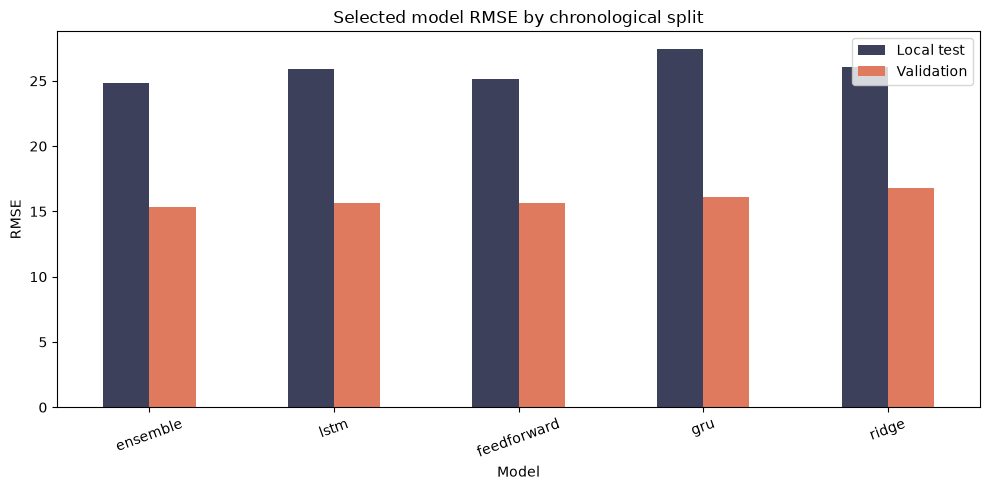

In [4]:
selected_models = comparison.loc[
    comparison["model"].isin(
        ["ridge", "feedforward", "lstm", "gru", "ensemble"]
    )
]
plot_data = selected_models.pivot(
    index="model",
    columns="split",
    values="rmse",
).sort_values("validation")

axis = plot_data.plot(
    kind="bar",
    figsize=(10, 5),
    color=["#3D405B", "#E07A5F"],
)
axis.set_title("Selected model RMSE by chronological split")
axis.set_xlabel("Model")
axis.set_ylabel("RMSE")
axis.tick_params(axis="x", rotation=20)
axis.legend(["Local test", "Validation"])
plt.tight_layout()
plt.show()

### Ensemble weight search

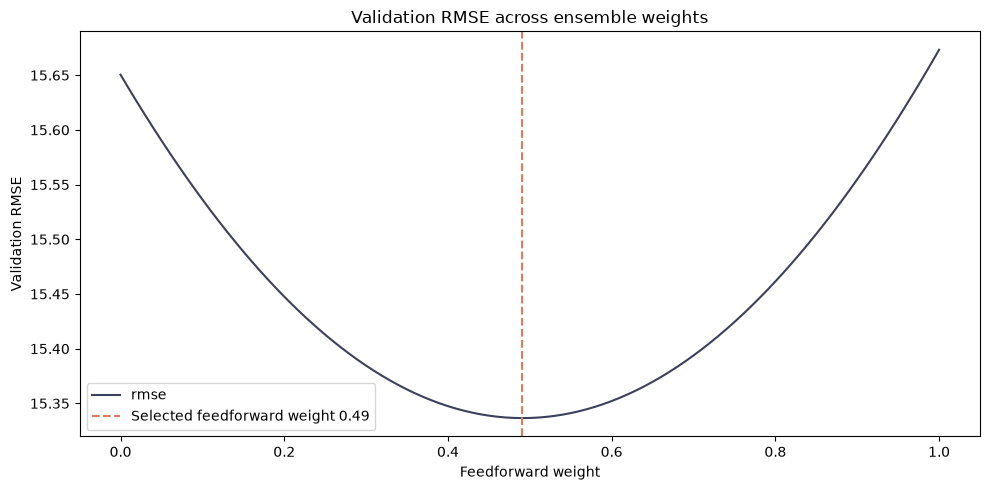

In [5]:
axis = weight_search.plot(
    x="feedforward_weight",
    y="rmse",
    figsize=(10, 5),
    color="#3D405B",
    legend=False,
)
axis.axvline(
    best_weight["feedforward_weight"],
    linestyle="--",
    color="#E07A5F",
    label=(
        "Selected feedforward weight "
        f"{best_weight['feedforward_weight']:.2f}"
    ),
)
axis.set_title("Validation RMSE across ensemble weights")
axis.set_xlabel("Feedforward weight")
axis.set_ylabel("Validation RMSE")
axis.legend()
plt.tight_layout()
plt.show()

### Selected Kaggle submission

In [6]:
sample_path = (
    PROJECT_ROOT / "data" / "raw" / "sample_submission.csv"
)
submission = pd.read_csv(SUBMISSION_PATH)
sample = pd.read_csv(sample_path)

assert submission.shape == (4_103, 2)
assert submission.columns.tolist() == ["id", "PM2.5"]
assert submission["id"].equals(sample["id"])
assert not submission["id"].duplicated().any()
assert submission["PM2.5"].notna().all()
assert np.isfinite(submission["PM2.5"]).all()
assert submission["PM2.5"].ge(0).all()

submission_sha256 = hashlib.sha256(
    SUBMISSION_PATH.read_bytes()
).hexdigest()

submission_view = pd.Series(
    {
        "filename": SUBMISSION_PATH.name,
        "rows": len(submission),
        "prediction_min": submission["PM2.5"].min(),
        "prediction_max": submission["PM2.5"].max(),
        "prediction_mean": submission["PM2.5"].mean(),
        "prediction_standard_deviation": submission["PM2.5"].std(),
        "sha256": submission_sha256,
    },
    name="value",
)
display(submission_view.to_frame())
display(submission.head())

,value
filename,submission_ensemble.csv
rows,4103
prediction_min,5.6579
prediction_max,577.8348
prediction_mean,76.6361
prediction_standard_deviation,80.3627
sha256,19a6c9ff68d12cdd7f17d87d88845d7f2eedfa12299492...


,id,PM2.5
0,test_00001,183.5058
1,test_00002,163.0109
2,test_00003,425.8467
3,test_00004,96.6494
4,test_00005,46.7346


In [7]:
selected_system = pd.Series(
    {
        "feedforward_weight": best_weight["feedforward_weight"],
        "lstm_weight": best_weight["lstm_weight"],
        "validation_rmse": ensemble.loc[
            ensemble["split"] == "validation", "rmse"
        ].iloc[0],
        "validation_mae": ensemble.loc[
            ensemble["split"] == "validation", "mae"
        ].iloc[0],
        "local_test_rmse": ensemble.loc[
            ensemble["split"] == "local_test", "rmse"
        ].iloc[0],
        "local_test_mae": ensemble.loc[
            ensemble["split"] == "local_test", "mae"
        ].iloc[0],
        "public_kaggle_rmse": 14.74409,
        "recorded_public_rank": 8,
    },
    name="value",
)
display(selected_system.to_frame())

,value
feedforward_weight,0.4900
lstm_weight,0.5100
validation_rmse,15.3365
validation_mae,8.2919
local_test_rmse,24.8339
local_test_mae,11.3179
public_kaggle_rmse,14.7441
recorded_public_rank,8.0000


### Selection record

In [8]:
EXPECTED_SUBMISSION_SHA256 = (
    "19a6c9ff68d12cdd7f17d87d88845d7f2eedfa122994921e0d2c6afb472db219"
)

assert submission_sha256 == EXPECTED_SUBMISSION_SHA256
assert np.isclose(best_weight["feedforward_weight"], 0.49)
assert np.isclose(best_weight["lstm_weight"], 0.51)

print("SELECTED 49/51 ENSEMBLE SUBMISSION VERIFIED")

SELECTED 49/51 ENSEMBLE SUBMISSION VERIFIED


### Kaggle checkpoint — recorded 2026-07-30

- Team: `DevOps`
- Best recorded public submission: `submission_ensemble.csv`
- Public RMSE: `14.74409`
- Selected local artefact: `submission_ensemble.csv`
- Recorded public rank: `8`

The competition uses separate public and private leaderboard
portions. The public result is therefore provisional and must not be
presented as an estimate of private-leaderboard performance.

## Takeaways

- The feedforward–LSTM ensemble is the strongest saved local model.
- The ensemble weight was selected without using local-test or
  Kaggle labels.
- The selected artefact is the original 0.49/0.51 ensemble produced
  from the two validated component models.
- The 4,103-row CSV passes format, ordering, uniqueness, finiteness,
  non-negativity, and checksum checks.
- `test_raw.csv` must never be used to reconstruct hidden labels or
  rank candidate submissions.

Remaining work:

1. publish the end-to-end Kaggle Notebook;
2. complete the AQI classification extension;
3. prepare the presentation, contribution evidence, AI-use
   declaration, and viva notes.

Reproduce and validate the final output:

```bash
conda activate co5420-air-gpu
python scripts/generate_submission.py --save-components
```